# Lab 10：迷你版的 rectified flow Transformer

對應講義：[第 10 課](../lessons/10_latent_diffusion_and_dit.md)

把前幾課的零件組合起來：**DiT（Transformer 骨幹）＋ flow matching（第 09 課）＋ classifier-free guidance（第 08 課）**。
這正是 Stable Diffusion 3／FLUX 的配方，只是少了潛空間與文字編碼器，換成 28×28 的數字與類別標籤。

1. 看 patchify：一張數字怎麼變成 49 個 token
2. 訓練 TinyDiT
3. 帶 guidance 生成，並掃描取樣步數
4. 看看模型學到了什麼：位置嵌入的空間結構

**執行時間**：CPU 上訓練約 15 分鐘（DiT 只有 49 個 token，在 CPU 上反而比 U-Net 快）。有 GPU 的話建議 `TRAIN_STEPS = 20000`、`EMA_DECAY = 0.999`。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


In [2]:
PATCH_SIZE = 4
WIDTH = 128
DEPTH = 4
HEADS = 4
TRAIN_STEPS = 3000
BATCH_SIZE = 128
LEARNING_RATE = 5e-4
EMA_DECAY = 0.995
P_UNCOND = 0.1
NUM_CLASSES = 10
NULL_CLASS = NUM_CLASSES

## 1. Patchify：影像變成 token

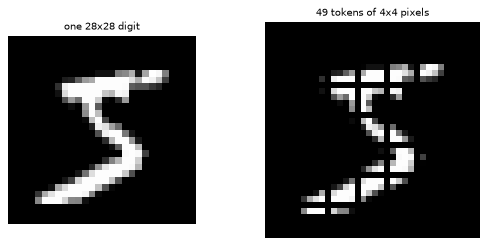

49 tokens, each a 16-dimensional vector before the linear projection to width 128


In [3]:
from diffusion_course.data import image_dataset
from diffusion_course.viz import show_images

digit = image_dataset("mnist", train=True)[0][0]
grid = 28 // PATCH_SIZE
patches = digit.reshape(1, grid, PATCH_SIZE, grid, PATCH_SIZE).permute(1, 3, 0, 2, 4).reshape(-1, 1, PATCH_SIZE, PATCH_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), gridspec_kw={"width_ratios": [1, 1.4]})
show_images(digit[None], axes[0], title="one 28x28 digit")
show_images(patches, axes[1], nrow=grid, title=f"{len(patches)} tokens of {PATCH_SIZE}x{PATCH_SIZE} pixels")
plt.show()
print(f"{len(patches)} tokens, each a {PATCH_SIZE * PATCH_SIZE}-dimensional vector before the linear projection to width {WIDTH}")

## 2. 訓練

損失是第 09 課的 `flow_matching_loss`，標籤先經過第 08 課的 `drop_labels`。模型換成 `TinyDiT`——其他什麼都不用改。

TinyDiT with 1,257,104 parameters


step 500/3000  loss 0.4529


step 1000/3000  loss 0.2864


step 1500/3000  loss 0.2626


step 2000/3000  loss 0.2490


step 2500/3000  loss 0.2276


step 3000/3000  loss 0.2095


trained 3000 steps in 15.0 min


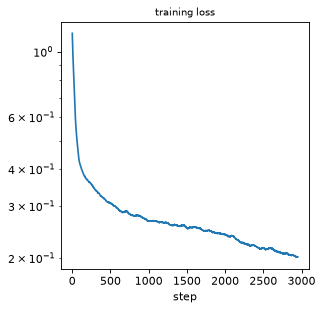

In [4]:
from diffusion_course.data import image_loader, infinite_batches
from diffusion_course.flow_matching import flow_matching_loss
from diffusion_course.guidance import drop_labels
from diffusion_course.models import TinyDiT
from diffusion_course.training import train
from diffusion_course.utils import count_parameters
from diffusion_course.viz import new_axes, plot_loss

model = TinyDiT(image_size=28, patch_size=PATCH_SIZE, dim=WIDTH, depth=DEPTH, num_heads=HEADS, num_classes=NUM_CLASSES)
print(f"TinyDiT with {count_parameters(model):,} parameters")


def loss_fn(m: torch.nn.Module, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return flow_matching_loss(m, x, drop_labels(y, P_UNCOND, NULL_CLASS))


result = train(
    model,
    loss_fn,
    infinite_batches(image_loader("mnist", BATCH_SIZE)),
    num_steps=TRAIN_STEPS,
    lr=LEARNING_RATE,
    ema_decay=EMA_DECAY,
    device=device,
    log_every=500,
)
ema_model = result.sampling_model
print(f"trained {TRAIN_STEPS} steps in {result.seconds / 60:.1f} min")
(ax,) = new_axes(1, size=4)
plot_loss(result.losses, ax, window=50)
plt.show()

## 3. 帶 guidance 生成

Heun 法 20 步（40 次網路評估），每列一個數字。左：$s = 1$（普通條件）；右：$s = 3$。

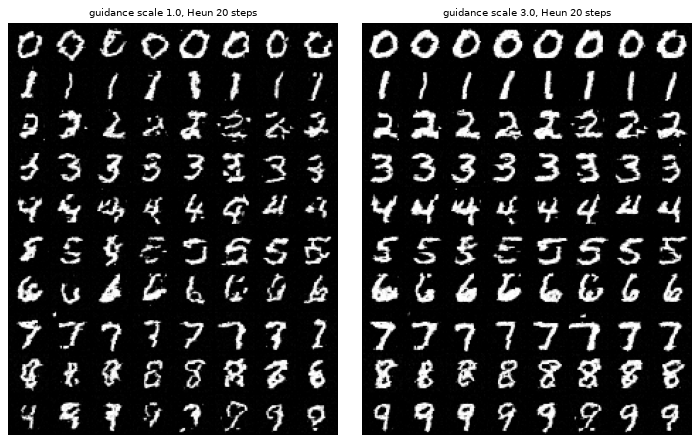

In [5]:
from diffusion_course.flow_matching import flow_sample
from diffusion_course.guidance import ClassifierFreeGuidance

PER_CLASS = 8
labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(PER_CLASS)
noise = torch.randn(len(labels), 1, 28, 28, device=device)

fig, axes = plt.subplots(1, 2, figsize=(9, 5.5))
for ax, scale in zip(axes, [1.0, 3.0]):
    guided = ClassifierFreeGuidance(ema_model, scale, NULL_CLASS)
    images = flow_sample(guided, noise.shape, num_steps=20, method="heun", y=labels, noise=noise, device=device)
    show_images(images.clamp(-1, 1), ax, nrow=PER_CLASS, title=f"guidance scale {scale}, Heun 20 steps")
plt.tight_layout()
plt.show()

## 4. 步數與求解器

$s = 3$，比較 Euler 與 Heun 在相同網路評估次數（NFE）下的表現。每個設定 500 張，除了分類器的 accuracy 與 confidence，
也量第 08 課的 **within-class diversity**（同一個數字的樣本之間的平均像素距離）。

solver  steps  NFE  accuracy  confidence  diversity


euler       2    2     1.000       0.998        8.7


heun        1    2     0.452       0.767       22.2


euler       4    4     1.000       0.998       12.0


heun        2    4     0.990       0.976       15.7


euler      10   10     1.000       0.998       13.7


heun        5   10     1.000       0.997       14.5


euler      40   40     1.000       0.997       14.5


heun       20   40     1.000       0.997       14.7


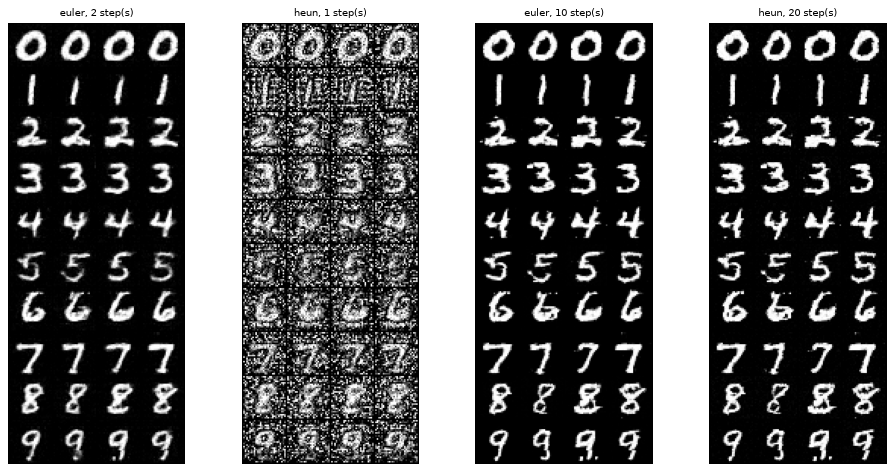

In [6]:
from diffusion_course.evaluation import get_digit_classifier, judge_samples

classifier = get_digit_classifier(device)
PER_CLASS_EVAL = 50
eval_labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(PER_CLASS_EVAL)
eval_noise = torch.randn(len(eval_labels), 1, 28, 28, device=device)
guided = ClassifierFreeGuidance(ema_model, 3.0, NULL_CLASS)
preview_index = torch.tensor([c * PER_CLASS_EVAL + k for c in range(NUM_CLASSES) for k in range(4)])


def within_class_diversity(images: torch.Tensor, labels: torch.Tensor) -> float:
    flat = images.flatten(1)
    return torch.stack([torch.pdist(flat[labels == c]).mean() for c in range(NUM_CLASSES)]).mean().item()


settings = [("euler", 2), ("heun", 1), ("euler", 4), ("heun", 2), ("euler", 10), ("heun", 5), ("euler", 40), ("heun", 20)]
previews = {}
print(f"{'solver':<7}{'steps':>6}{'NFE':>5}{'accuracy':>10}{'confidence':>12}{'diversity':>11}")
for method, steps in settings:
    images = flow_sample(guided, eval_noise.shape, num_steps=steps, method=method, y=eval_labels, noise=eval_noise, device=device).clamp(-1, 1)
    judged = judge_samples(classifier, images, eval_labels)
    nfe = steps * (2 if method == "heun" else 1)
    diversity = within_class_diversity(images, eval_labels)
    print(f"{method:<7}{steps:>6}{nfe:>5}{judged['accuracy']:>10.3f}{judged['confidence']:>12.3f}{diversity:>11.1f}")
    previews[(method, steps)] = images[preview_index.to(images.device)]

shown = [("euler", 2), ("heun", 1), ("euler", 10), ("heun", 20)]
fig, axes = plt.subplots(1, len(shown), figsize=(3 * len(shown), 6))
for ax, key in zip(axes, shown):
    show_images(previews[key], ax, nrow=4, title=f"{key[0]}, {key[1]} step(s)")
plt.tight_layout()
plt.show()

讀表讀圖：

- **只看 accuracy 與 confidence，幾乎每個設定都是滿分**（Heun 1 步除外）——分類器分不出好壞。
- **看 diversity 與圖就不一樣了**：Euler 2 步的 diversity 只有 8.7，同一個數字的四張圖幾乎一模一樣，是一張「類別原型」。從雜訊一大步跳到 $t = 0.5$，模型給的是條件平均的方向；guidance 再把這個平均變清楚。步數增加後，diversity 回升到 14.5 左右並穩定下來。
- **Heun 1 步最差**：它的第二次評估落在 $t = 1$、位置是一張模糊的平均圖，模型在那裡的速度不可靠，結果殘留大量雜訊。它的 diversity（22.2）高，是雜訊造成的「假多樣性」。
- 同樣 10 次網路評估時，Heun 5 步（14.5）比 Euler 10 步（13.7）略好；評估次數只有 2–4 次時，Euler 反而比較穩。

教訓：**品質指標高不代表好（可能只是原型），多樣性高也不代表好（可能只是雜訊）**。評估生成模型要同時看兩者，這正是 FID 想用一個數字同時捕捉的東西（第 06 課 §2.5）。

## 5. 模型學到了什麼：位置嵌入

`TinyDiT` 的位置嵌入是可學習的，初始化時完全隨機，沒有任何「哪兩個 patch 相鄰」的資訊。
訓練後，計算某個 patch 的位置嵌入和其他 49 個位置的餘弦相似度，畫回 7×7 的格子上：

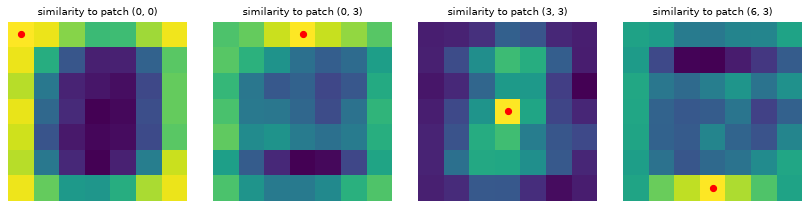

In [7]:
pos = torch.nn.functional.normalize(ema_model.pos_embed[0].detach().cpu(), dim=1)
similarity = pos @ pos.T
anchors = [0, 3, 24, 45]  # corner, top edge, centre, bottom edge

fig, axes = plt.subplots(1, len(anchors), figsize=(2.6 * len(anchors), 2.6))
for ax, anchor in zip(axes, anchors):
    ax.imshow(similarity[anchor].reshape(grid, grid), cmap="viridis")
    row, col = divmod(anchor, grid)
    ax.scatter([col], [row], color="red", s=30)
    ax.set_title(f"similarity to patch ({row}, {col})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

結果和「相鄰的 patch 位置嵌入會相似」的直覺**不一樣**：角落 $(0, 0)$ 和整圈邊框都很像，中心 $(3, 3)$ 則和中央區域比較像。
模型學到的主要結構是**「邊框 vs. 內部」**：MNIST 的邊框永遠是黑的，對去噪來說，「這個 patch 在不在邊框上」遠比「它的左右鄰居是誰」有用。
位置嵌入學到什麼，取決於資料裡什麼資訊有用。原始 DiT 用固定的 2D sin-cos 位置嵌入，把「相鄰」的結構直接寫死（講義練習 5 可以比較兩者）。

## 6. 存檔

In [8]:
from diffusion_course.training import save_checkpoint
from diffusion_course.utils import CHECKPOINT_DIR

save_checkpoint(
    CHECKPOINT_DIR / "lab10_mnist_flow_dit_cond.pt",
    ema_model,
    arch="dit",
    model_kwargs={"image_size": 28, "patch_size": PATCH_SIZE, "dim": WIDTH, "depth": DEPTH, "num_heads": HEADS, "num_classes": NUM_CLASSES},
    method="flow",
    dataset="mnist",
    num_classes=NUM_CLASSES,
)

saved checkpoint to checkpoints/lab10_mnist_flow_dit_cond.pt


這個檢查點也能用命令列取樣：`uv run python scripts/sample_mnist.py checkpoints/lab10_mnist_flow_dit_cond.pt --guidance-scale 3`。

## 小結

- DiT ＋ flow matching ＋ CFG：三個零件都是前幾課做好的，組合起來只要換一行模型。
- 這就是 2024 年以後主流文生圖模型的核心配方，差別在規模、潛空間與文字編碼器。
- 少步數時，分類器指標可能「滿分」但樣本毫無多樣性：評估生成模型一定要同時看品質與多樣性（這正是 FID 想同時捕捉的兩件事）。
- 從隨機初始化學出的位置嵌入，反映的是對這份資料有用的結構（邊框 vs. 內部），不一定是我們直覺中的「相鄰」。

最後一課：這個領域在 2026 年往哪裡走。